In [6]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor

In [ ]:
df = pd.read_csv("eda_dataset.csv")

In [ ]:
df.head()

In [ ]:
df.info()

In [10]:
df['datetime'] = pd.to_datetime(df[['Year','Month','Day','Hour','Minute']])
df = df.sort_values('datetime')

In [11]:
df = df.drop(columns=['AQI_Bucket'])

In [12]:
df['aqi_lag1'] = df['AQI'].shift(1)
df['aqi_lag2'] = df['AQI'].shift(2)
df['aqi_lag3'] = df['AQI'].shift(3)

In [ ]:
df

In [14]:
df['aqi_roll3'] = df['AQI'].rolling(3).mean()
df['aqi_roll6'] = df['AQI'].rolling(6).mean()

In [15]:
df = df.dropna()

In [16]:
df.shape

(152057, 25)

In [17]:
X = df.drop(columns=['AQI', 'datetime'])
y = df['AQI']

In [ ]:
df

In [ ]:
df.shape

In [20]:
split = int(len(df)*0.8)

X_train = X.iloc[:split]
X_test = X.iloc[split:]

y_train = y.iloc[:split]
y_test = y.iloc[split:]

In [21]:
model = XGBRegressor(
    n_estimators=300,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8
)

In [33]:
model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=8,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=None, num_parallel_tree=None, ...)

In [23]:
y_pred = model.predict(X_test)

In [24]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

In [25]:
accuracy = r2_score(y_test, y_pred)

In [32]:
print("RMSE:", rmse)
print("MAE:", mae)
print("Acuracy: ", accuracy)

RMSE: 26.036878832619745
MAE: 15.031132420661903
Acuracy:  0.9589556107536921


In [27]:
y_pred

array([102.21952 , 348.53876 , 115.530045, ...,  54.577866,  74.205536,
        52.840435], dtype=float32)

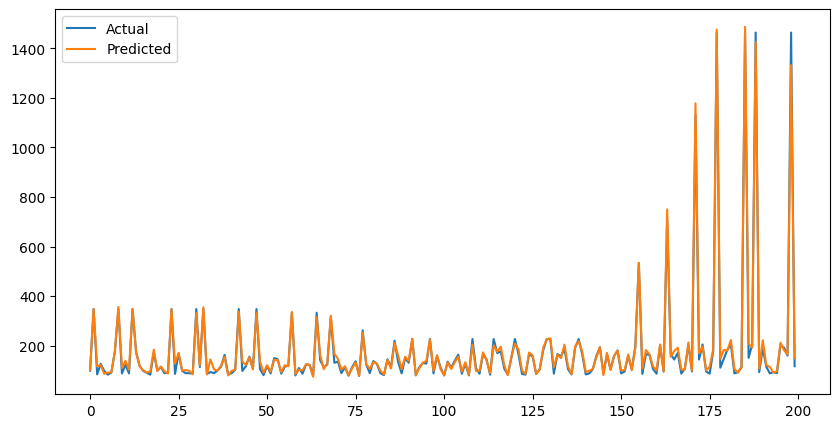

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(y_test.values[:200], label="Actual")
plt.plot(y_pred[:200], label="Predicted")
plt.legend()
plt.show()

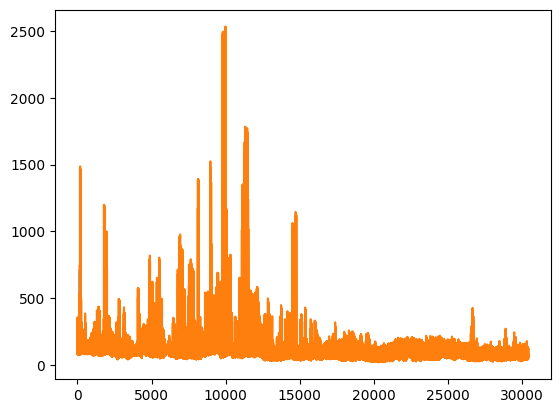

In [29]:
plt.plot(y_test.values[:200], label="Actual")
plt.plot(y_pred[:-1], label="Predicted (shifted)")

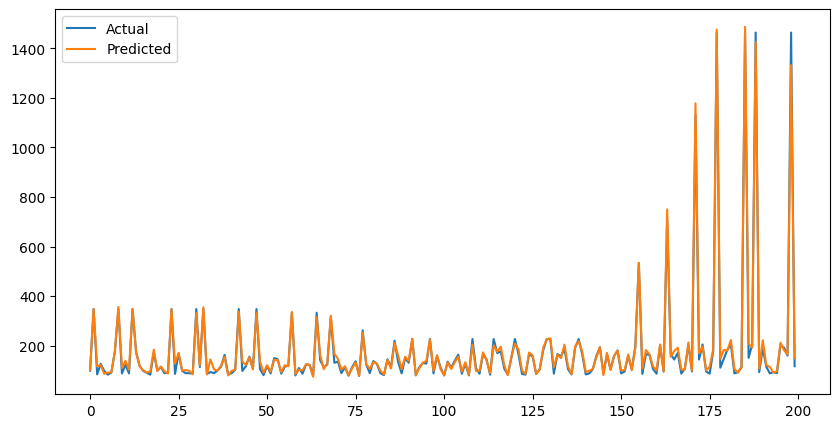

In [30]:
plt.figure(figsize=(10,5))

plt.plot(y_test.values[:200], label="Actual")
plt.plot(y_pred[:200], label="Predicted")

plt.legend()
plt.show()

In [34]:
import joblib
joblib.dump(model, "xgb_model_neha.pkl")

['xgb_model_neha.pkl']